In [1]:
import sys, os
os.chdir('..')
sys.path.append('.')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_loader import load_ratings, load_movies, get_train_test_split
from src.collaborative_filtering import CollaborativeFilteringModel

%matplotlib inline

ratings = load_ratings()
movies = load_movies()
train, test = get_train_test_split(ratings)

cf_model = CollaborativeFilteringModel(n_factors=20, learning_rate=0.01, n_epochs=20)
cf_model.fit(train)

print("Model trained successfully!")

Epoch 1/20 - Training RMSE: 1.0215
Epoch 2/20 - Training RMSE: 0.9581
Epoch 3/20 - Training RMSE: 0.9394
Epoch 4/20 - Training RMSE: 0.9282
Epoch 5/20 - Training RMSE: 0.9196
Epoch 6/20 - Training RMSE: 0.9117
Epoch 7/20 - Training RMSE: 0.9033
Epoch 8/20 - Training RMSE: 0.8938
Epoch 9/20 - Training RMSE: 0.8825
Epoch 10/20 - Training RMSE: 0.8696
Epoch 11/20 - Training RMSE: 0.8553
Epoch 12/20 - Training RMSE: 0.8403
Epoch 13/20 - Training RMSE: 0.8250
Epoch 14/20 - Training RMSE: 0.8096
Epoch 15/20 - Training RMSE: 0.7944
Epoch 16/20 - Training RMSE: 0.7796
Epoch 17/20 - Training RMSE: 0.7655
Epoch 18/20 - Training RMSE: 0.7522
Epoch 19/20 - Training RMSE: 0.7398
Epoch 20/20 - Training RMSE: 0.7282
Model trained successfully!


In [2]:
GENRE_NAMES = [
    "unknown", "Action", "Adventure", "Animation", "Children's", "Comedy",
    "Crime", "Documentary", "Drama", "Fantasy", "Film-Noir", "Horror",
    "Musical", "Mystery", "Romance", "Sci-Fi", "Thriller", "War", "Western"
]

# Test set ke har rating ke liye prediction aur error nikalte hain
test_with_preds = test.copy()
test_with_preds['predicted_rating'] = test_with_preds.apply(
    lambda row: cf_model.predict(row['user_id'], row['item_id']), axis=1
)
test_with_preds['error'] = abs(test_with_preds['rating'] - test_with_preds['predicted_rating'])

# Movies ko genre info ke sath merge karte hain
test_with_genres = test_with_preds.merge(movies, on='item_id')

# Har genre ke liye average error calculate karte hain
genre_errors = {}
for i, genre in enumerate(GENRE_NAMES):
    genre_col = f'genre_{i}'
    genre_subset = test_with_genres[test_with_genres[genre_col] == 1]
    if len(genre_subset) > 0:
        genre_errors[genre] = {
            'avg_error': genre_subset['error'].mean(),
            'count': len(genre_subset)
        }

genre_errors_df = pd.DataFrame(genre_errors).T.sort_values('avg_error', ascending=False)
print("Average Prediction Error by Genre:")
genre_errors_df

Average Prediction Error by Genre:


,avg_error,count
Documentary,0.870124,154.0
Horror,0.804309,1063.0
Musical,0.798732,988.0
Children's,0.760225,1426.0
Comedy,0.747706,5966.0
Sci-Fi,0.734266,2595.0
Romance,0.726850,3980.0
Drama,0.724853,7941.0
Crime,0.722303,1581.0
Western,0.722073,337.0


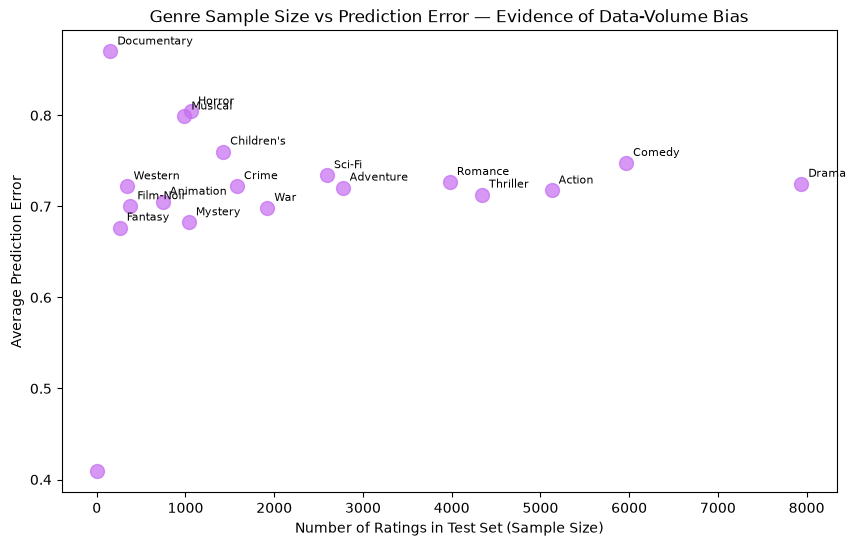

In [3]:
plt.figure(figsize=(10, 6))
plt.scatter(genre_errors_df['count'], genre_errors_df['avg_error'], s=100, alpha=0.7, color='#c56cf0')

for genre in genre_errors_df.index:
    if genre != 'unknown':
        plt.annotate(genre, (genre_errors_df.loc[genre, 'count'], genre_errors_df.loc[genre, 'avg_error']),
                     fontsize=8, xytext=(5, 5), textcoords='offset points')

plt.xlabel('Number of Ratings in Test Set (Sample Size)')
plt.ylabel('Average Prediction Error')
plt.title('Genre Sample Size vs Prediction Error — Evidence of Data-Volume Bias')
plt.savefig('notebooks/genre_bias_analysis.png')
plt.show()

In [4]:
# Har movie ki popularity (training mein kitni baar rate hui) nikalte hain
movie_popularity = train.groupby('item_id')['rating'].count().rename('popularity')

test_with_pop = test_with_preds.merge(movie_popularity, on='item_id', how='left')
test_with_pop['popularity'] = test_with_pop['popularity'].fillna(0)

# Movies ko popularity ke hisaab se buckets mein baantte hain
def popularity_bucket(count):
    if count < 10:
        return "Very Low (<10)"
    elif count < 50:
        return "Low (10-49)"
    elif count < 150:
        return "Medium (50-149)"
    else:
        return "High (150+)"

test_with_pop['popularity_bucket'] = test_with_pop['popularity'].apply(popularity_bucket)

bucket_order = ["Very Low (<10)", "Low (10-49)", "Medium (50-149)", "High (150+)"]
popularity_bias = test_with_pop.groupby('popularity_bucket')['error'].agg(['mean', 'count']).reindex(bucket_order)

print("Prediction Error by Movie Popularity:")
popularity_bias

Prediction Error by Movie Popularity:


,mean,count
popularity_bucket,,
Very Low (<10),0.891828,630
Low (10-49),0.757847,3663
Medium (50-149),0.735481,8471
High (150+),0.708339,7236


C:\Users\noorf\AppData\Local\Temp\ipykernel_9520\4082266254.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=popularity_bias.index, y=popularity_bias['mean'], palette='magma')


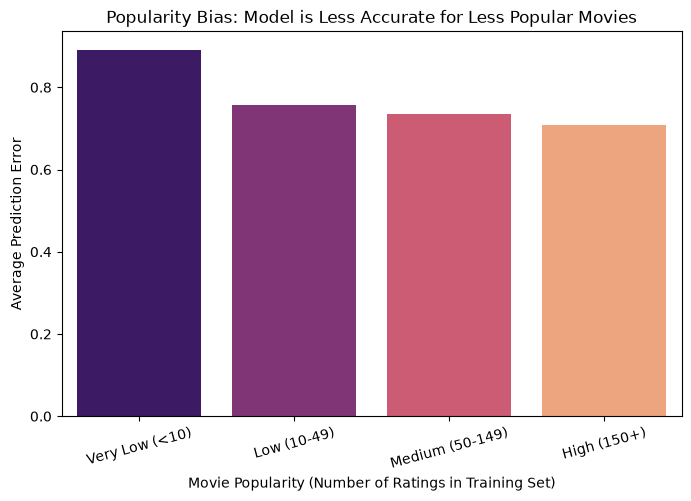

In [5]:
plt.figure(figsize=(8, 5))
sns.barplot(x=popularity_bias.index, y=popularity_bias['mean'], palette='magma')
plt.xlabel('Movie Popularity (Number of Ratings in Training Set)')
plt.ylabel('Average Prediction Error')
plt.title('Popularity Bias: Model is Less Accurate for Less Popular Movies')
plt.xticks(rotation=15)
plt.savefig('notebooks/popularity_bias_analysis.png')
plt.show()

## Bias Analysis Findings

### 1. Genre-Level Bias
Prediction error varies across genres, with a general (though not perfectly linear) tendency
for genres with fewer ratings in the dataset (e.g. Documentary, Horror, Musical) to have
higher average prediction error than genres with abundant data (e.g. Drama, Comedy). This
suggests the model's accuracy is partly influenced by how much training data exists for a
given genre, though genre-specific characteristics likely also play a role.

### 2. Popularity Bias (Primary Finding)
A much clearer and more consistent pattern was found based on movie popularity:

| Popularity Bucket | Avg Prediction Error |
|---|---|
| Very Low (<10 ratings) | 0.89 |
| Low (10-49 ratings) | 0.76 |
| Medium (50-149 ratings) | 0.74 |
| High (150+ ratings) | 0.71 |

The model is measurably **less accurate for niche/unpopular movies** than for popular ones
— a ~26% increase in error between the least and most popular buckets. This is a well-known
form of bias in collaborative filtering systems: items with little interaction data receive
less reliable predictions, which can create a feedback loop where already-popular items keep
getting recommended and niche items are further overlooked.

### Implication
This finding reinforces the value of the hybrid model built in this project. Content-based
filtering, which relies on item metadata rather than interaction history, is not subject to
this same popularity bias — it can make reasonable recommendations for niche movies purely
based on genre similarity. The switching strategy implemented in `hybrid_model.py` (falling
back to content-based recommendations for users with sparse history) partially mitigates
the practical impact of this bias, though the underlying collaborative filtering model's
accuracy gap for unpopular items remains a documented limitation.